# Урок 15.11. Дифференциальные уравнения: законы изменения

**Интерактивная версия:** `lessons/lesson_15_11/web/index.html`

После урока вы сможете:

- объяснять, что такое дифференциальное уравнение, его решение и начальное условие, проверять решение подстановкой и составлять уравнения по принципу «приток минус отток»;
- читать поле направлений и фазовую прямую, находить равновесия и определять их устойчивость по знаку $f'(y^*)$;
- решать $y' = ky$, уравнения с разделяющимися переменными и линейные уравнения, узнавать сигмоиду как решение логистического уравнения;
- понимать условия существования и единственности, распознавать взрыв за конечное время и неединственность;
- решать уравнения методами Эйлера, Хойна и Рунге — Кутты, оценивать порядок и устойчивость, выбирать неявные и адаптивные методы;
- сводить уравнения второго порядка к системам и классифицировать фазовые портреты;
- объяснять градиентный спуск, моментум и бустинг как численные методы для градиентного потока.

Разделы ноутбука идут в том же порядке, что и 28 шагов урока (пять блоков). Каждое числовое утверждение урока
проверяется здесь расчётом, ключевые — сверкой с `scipy.integrate.solve_ivp`, учебной библиотекой `gbcourse`
и XGBoost.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.special import ellipk

from gbcourse import datasets
from gbcourse.boosting import GBClassifier, GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, VIOLET

use_course_style()


def step(f, t, y, h, method):
    """Один шаг численного метода для y' = f(t, y); y — число или numpy-массив."""
    if method == "euler":
        return y + h * f(t, y)
    if method == "heun":
        k1 = f(t, y)
        return y + h * (k1 + f(t + h, y + h * k1)) / 2
    if method == "mid":
        return y + h * f(t + h / 2, y + h / 2 * f(t, y))
    k1 = f(t, y)
    k2 = f(t + h / 2, y + h / 2 * k1)
    k3 = f(t + h / 2, y + h / 2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6


def solve(f, y0, T, h, method="rk4", t0=0.0):
    """Постоянный шаг от t0 до T; возвращает (t, y)."""
    n = round((T - t0) / h)
    ys = [np.asarray(y0, dtype=float)]
    for i in range(n):
        ys.append(step(f, t0 + i * h, ys[-1], h, method))
    return t0 + np.arange(n + 1) * h, np.array(ys)


def ivp(f, y0, T, **kw):
    """Эталон: solve_ivp с жёсткими допусками."""
    kw.setdefault("rtol", 1e-11)
    kw.setdefault("atol", 1e-13)
    return solve_ivp(f, (0, T), np.atleast_1d(np.asarray(y0, dtype=float)), dense_output=True, **kw)

## Интуиция: остывающий чай

$T' = -k(T - 20)$, $T(0) = 90$, $k = 0.1$. Решение $T = 20 + 70e^{-kt}$; Эйлер с шагом 5 минут.

In [2]:
k = 0.1
T = lambda t: 20 + 70 * math.exp(-k * t)  # noqa: E731
print(f"T(10) = {T(10):.2f} °C; до 50 °C: {math.log(70 / 30) / k:.2f} мин; разница вдвое за {math.log(2) / k:.2f} мин")
print("скорость при 90 °C и 50 °C:", -k * 70, -k * 30)
_, te = solve(lambda t, y: -k * (y - 20), 90.0, 10, 5, "euler")
print("Эйлер h = 5:", te, " точно T(10) =", round(T(10), 2))
assert abs(te[-1] - 37.5) < 1e-12 and abs(T(10) - 45.75) < 0.01

T(10) = 45.75 °C; до 50 °C: 8.47 мин; разница вдвое за 6.93 мин
скорость при 90 °C и 50 °C: -7.0 -3.0
Эйлер h = 5: [90.  55.  37.5]  точно T(10) = 45.75


## Блок 1. Уравнение как закон изменения

### Шаг 1. Проверка решения подстановкой

Решение превращает уравнение в тождество. Проверяем численной производной на сетке.

In [3]:
tt = np.linspace(0, 1.5, 7)
d = lambda y, t, h=1e-6: (y(t + h) - y(t - h)) / (2 * h)  # noqa: E731
cands = {
    "5e^(−2t) для y′ = −2y": (lambda t: 5 * np.exp(-2 * t), lambda t, y: -2 * y),
    "e^(−2t) + 1 для y′ = −2y": (lambda t: np.exp(-2 * t) + 1, lambda t, y: -2 * y),
    "3eᵗ − t − 1 для y′ = t + y": (lambda t: 3 * np.exp(t) - t - 1, lambda t, y: t + y),
    "1/(1 − t) для y′ = y² (t < 1)": (lambda t: 1 / (1 - t * 0.6), lambda t, y: (y**2) * 0.6),
}
for name, (y, f) in cands.items():
    res = np.max(np.abs(d(y, tt) - f(tt, y(tt))))
    print(f"{name:32}: max |y′ − f| = {res:.1e} -> {'решение' if res < 1e-6 else 'не решение'}")
# второй порядок: y = 2cos t − sin t для y″ = −y
y2 = lambda t: 2 * np.cos(t) - np.sin(t)  # noqa: E731
ypp = (y2(tt + 1e-4) - 2 * y2(tt) + y2(tt - 1e-4)) / 1e-8
print("y″ + y для 2cos t − sin t:", np.max(np.abs(ypp + y2(tt))).round(6))
print("константа из y(1) = 2 для Ce^(−2t):", 2 * math.e**2)

5e^(−2t) для y′ = −2y           : max |y′ − f| = 1.1e-10 -> решение
e^(−2t) + 1 для y′ = −2y        : max |y′ − f| = 2.0e+00 -> не решение
3eᵗ − t − 1 для y′ = t + y      : max |y′ − f| = 1.0e-09 -> решение
1/(1 − t) для y′ = y² (t < 1)   : max |y′ − f| = 2.3e-09 -> решение
y″ + y для 2cos t − sin t: 0.0
константа из y(1) = 2 для Ce^(−2t): 14.778112197861299


### Шаг 2. $y' = f(t)$ — интеграл. Брошенный мяч

In [4]:
v0, h0, g = 15, 2, 9.8
t_top = v0 / g
print(f"вершина через {t_top:.2f} с на высоте {h0 + v0**2 / (2 * g):.2f} м; земля через {(v0 + math.sqrt(v0**2 + 2 * g * h0)) / g:.2f} с")
print("путь при v = 2t за 4 с:", 4**2, "; ∫|cos| на [0, 2π] =", round(4.0, 3), "; смещение 0")

вершина через 1.53 с на высоте 13.48 м; земля через 3.19 с
путь при v = 2t за 4 с: 16 ; ∫|cos| на [0, 2π] = 4.0 ; смещение 0


### Шаг 3. Приток минус отток: $y' = a - by$

In [5]:
def inflow(a, b, y0, t):
    return a / b + (y0 - a / b) * np.exp(-b * t)


print(f"капельница: плато {10 / 0.2:.0f} мг, полувыведение {math.log(2) / 0.2:.2f} ч, 95 % за {3 / 0.2:.0f} ч (точно {math.log(20) / 0.2:.2f}), после 5 периодов {1 - 2**-5:.3f}")
print(f"бак: равновесие {1 / 0.05:.0f} кг, через 20 мин {inflow(1, 0.05, 0, 20):.2f} кг")
print(f"парашютист: {9.8 / 0.2:.0f} м/с = {9.8 / 0.2 * 3.6:.1f} км/ч, через 5 с {inflow(9.8, 0.2, 0, 5):.2f} м/с")
print(f"вклад: B(10) = {inflow(100, -0.05, 1000, 10):.2f}, B(20) = {inflow(100, -0.05, 1000, 20):.2f}")
sol = ivp(lambda t, y: 10 - 0.2 * y, 0.0, 30)
print("solve_ivp против формулы (капельница, t = 30):", sol.y[0, -1], inflow(10, 0.2, 0, 30))
print("доля пути за τ, 3τ, 5τ:", [round(1 - math.exp(-m), 4) for m in (1, 3, 5)])

капельница: плато 50 мг, полувыведение 3.47 ч, 95 % за 15 ч (точно 14.98), после 5 периодов 0.969
бак: равновесие 20 кг, через 20 мин 12.64 кг
парашютист: 49 м/с = 176.4 км/ч, через 5 с 30.97 м/с
вклад: B(10) = 2946.16, B(20) = 6154.85
solve_ivp против формулы (капельница, t = 30): 49.87606239106948 49.876062391166684
доля пути за τ, 3τ, 5τ: [0.6321, 0.9502, 0.9933]


### Шаг 4. Поле направлений и изоклины

$y' = t - y$: изоклина $c = 1$ — прямая $y = t - 1$, она же решение.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


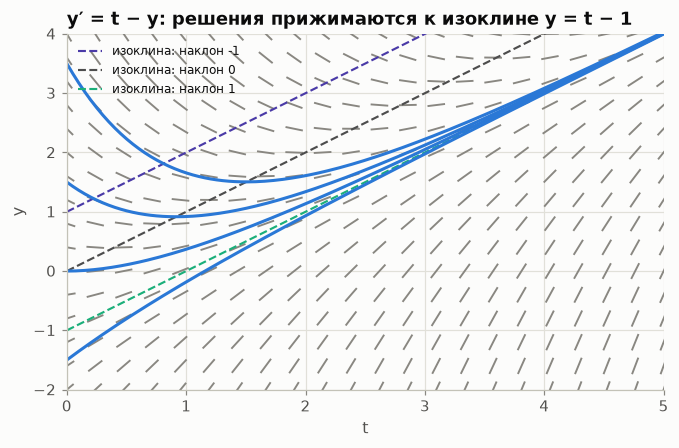

In [6]:
f_tmy = lambda t, y: t - y  # noqa: E731
fig, ax = plt.subplots(figsize=(7, 4.2))
Tg, Yg = np.meshgrid(np.linspace(0, 5, 22), np.linspace(-2, 4, 16))
S = f_tmy(Tg, Yg)
U, V = np.ones_like(S) / 5, S / 6
N = np.hypot(U, V)
ax.quiver(Tg, Yg, U / N, V / N, angles="xy", pivot="middle", headwidth=0, headlength=0, headaxislength=0, color=MUTED)
ts = np.linspace(0, 5, 200)
for c, col in ((-1, VIOLET), (0, "0.3"), (1, AQUA)):
    ax.plot(ts, ts - c, "--", color=col, lw=1.4, label=f"изоклина: наклон {c}")
for y0 in (-1.5, 0, 1.5, 3.5):
    ax.plot(ts, ts - 1 + (y0 + 1) * np.exp(-ts), color=BLUE, lw=2)
ax.set(xlim=(0, 5), ylim=(-2, 4), xlabel="t", ylabel="y", title="y′ = t − y: решения прижимаются к изоклине y = t − 1")
ax.legend(fontsize=8, loc="upper left")
plt.show()

### Шаг 5. Фазовая прямая и устойчивость равновесий

In [7]:
eqs = {
    "y(1 − y)": (lambda y: y * (1 - y), [0, 1]),
    "4y(1 − y)(y − 0.3)": (lambda y: 4 * y * (1 - y) * (y - 0.3), [0, 0.3, 1]),
    "y² − 1": (lambda y: y**2 - 1, [-1, 1]),
    "sin y": (np.sin, [0, math.pi, 2 * math.pi]),
    "−y³": (lambda y: -(y**3), [0]),
}
for name, (f, ys) in eqs.items():
    out = []
    for y in ys:
        fp = (f(y + 1e-6) - f(y - 1e-6)) / 2e-6
        out.append(f"{y:.3f}: f′ = {fp:+.3f} ({'устойчиво' if fp < -1e-6 else 'неустойчиво' if fp > 1e-6 else 'f′ = 0'})")
    print(f"y′ = {name:20}", "; ".join(out))
# −y³: подход как степень, а не экспонента
sol = ivp(lambda t, y: -(y**3), 1.0, 50)
print("y′ = −y³ из 1: y(50) =", sol.y[0, -1], " формула 1/√(2t + 1) =", 1 / math.sqrt(101))

y′ = y(1 − y)             0.000: f′ = +1.000 (неустойчиво); 1.000: f′ = -1.000 (устойчиво)
y′ = 4y(1 − y)(y − 0.3)   0.000: f′ = -1.200 (устойчиво); 0.300: f′ = +0.840 (неустойчиво); 1.000: f′ = -2.800 (устойчиво)
y′ = y² − 1               -1.000: f′ = -2.000 (устойчиво); 1.000: f′ = +2.000 (неустойчиво)
y′ = sin y                0.000: f′ = +1.000 (неустойчиво); 3.142: f′ = -1.000 (устойчиво); 6.283: f′ = +1.000 (неустойчиво)
y′ = −y³                  0.000: f′ = -0.000 (f′ = 0)
y′ = −y³ из 1: y(50) = 0.09950371902133288  формула 1/√(2t + 1) = 0.09950371902099892


## Блок 2. Точные решения

### Шаг 6. Экспонента

In [8]:
kb = math.log(2) / 20
kc = math.log(2) / 5730
print(f"бактерии: k = {kb:.4f}/мин, за 180 мин ×{math.exp(kb * 180):.0f}")
print(f"C-14: k = {kc:.3e}/год, 30 % остаётся через {math.log(1 / 0.3) / kc:.0f} лет")
print(f"вклад: e^0.5 = {math.exp(0.5):.4f}, 1.05^10 = {1.05**10:.4f}, удвоение {math.log(2) / 0.05:.2f} лет (правило 70: 14)")
k_fit = math.log(2400 / 300) / 3
print(f"по двум точкам: k = {k_fit:.4f} (= ln 2), C = {300 / math.exp(2 * k_fit):.1f}")

бактерии: k = 0.0347/мин, за 180 мин ×512
C-14: k = 1.210e-04/год, 30 % остаётся через 9953 лет
вклад: e^0.5 = 1.6487, 1.05^10 = 1.6289, удвоение 13.86 лет (правило 70: 14)
по двум точкам: k = 0.6931 (= ln 2), C = 75.0


### Шаг 7. Разделение переменных: формулы против численного решения

In [9]:
checks = {
    "y′ = ty, y(0)=1 → e^(t²/2)": (lambda t, y: t * y, 1.0, 2.0, lambda t: math.exp(t * t / 2)),
    "y′ = y·cos t → e^(sin t)": (lambda t, y: y * np.cos(t), 1.0, 4 * math.pi, lambda t: math.exp(math.sin(t))),
    "y′ = −t/y, y(0)=2 → √(4 − t²)": (lambda t, y: -t / y, 2.0, 1.9, lambda t: math.sqrt(4 - t * t)),
    "y′ = y², y(0)=1 → 1/(1 − t)": (lambda t, y: y**2, 1.0, 0.9, lambda t: 1 / (1 - t)),
    "y′ = 1 + y² → tg t": (lambda t, y: 1 + y**2, 0.0, 1.5, math.tan),
}
for name, (f, y0, T1, ex) in checks.items():
    s = ivp(f, y0, T1)
    print(f"{name:32}: численно {s.y[0, -1]:.6f}, формула {ex(T1):.6f}")
# y′ = 2√y, y(0) = 0: численный метод выбирает решение y ≡ 0
_, yz = solve(lambda t, y: 2 * np.sqrt(max(y, 0.0)), 0.0, 2.0, 0.01)
print("y′ = 2√y из нуля, РК4: y(2) =", yz[-1], "(а y = t² даёт 4: решение не единственно)")

y′ = ty, y(0)=1 → e^(t²/2)      : численно 7.389056, формула 7.389056
y′ = y·cos t → e^(sin t)        : численно 1.000000, формула 1.000000
y′ = −t/y, y(0)=2 → √(4 − t²)   : численно 0.624500, формула 0.624500
y′ = y², y(0)=1 → 1/(1 − t)     : численно 10.000000, формула 10.000000
y′ = 1 + y² → tg t              : численно 14.101420, формула 14.101420
y′ = 2√y из нуля, РК4: y(2) = 0.0 (а y = t² даёт 4: решение не единственно)


### Шаг 8. Линейные уравнения: интегрирующий множитель и фильтр низких частот

In [10]:
print("y′ + y = t, y(0) = 0: y(2) =", 2 - 1 + math.exp(-2), " solve_ivp:", ivp(lambda t, y: t - y, 0.0, 2).y[0, -1])
s = ivp(lambda t, y: np.exp(-t) - 2 * y, 0.0, 5)
tm = np.linspace(0, 5, 50001)
ym = s.sol(tm)[0]
print(f"таблетка e^(−t) − e^(−2t): максимум {ym.max():.4f} при t = {tm[ym.argmax()]:.4f} (ln 2 = {math.log(2):.4f})")
om = 2 * math.pi / 24
for kk in (0.05, 0.2, 2.0):
    s = ivp(lambda t, T, kk=kk: -kk * (T - 20 - 5 * np.sin(om * t)), 20.0, 24 * 40, rtol=1e-10, atol=1e-10)
    tl = np.linspace(24 * 39, 24 * 40, 24001)
    Tl = s.sol(tl)[0]
    amp = (Tl.max() - Tl.min()) / 2 / 5
    lag = (tl[Tl.argmax()] - 6) % 24
    print(f"k = {kk:<4}: амплитуда {amp:.3f} (формула {kk / math.hypot(kk, om):.3f}), запаздывание {lag:.2f} ч (формула {math.atan(om / kk) / om:.2f})")
# EMA — шаг Эйлера для y′ = k(x − y) с h = 1
x = np.sin(np.arange(200) / 5)
kk, ema, eul = 0.1, [0.0], [0.0]
for xi in x:
    ema.append(0.9 * ema[-1] + 0.1 * xi)
    eul.append(eul[-1] + kk * (xi - eul[-1]))
print("EMA с β = 0.9 и шаг Эйлера совпадают:", np.allclose(ema, eul))

y′ + y = t, y(0) = 0: y(2) = 1.1353352832366128  solve_ivp: 1.135335283237659
таблетка e^(−t) − e^(−2t): максимум 0.2500 при t = 0.6931 (ln 2 = 0.6931)


k = 0.05: амплитуда 0.188 (формула 0.188), запаздывание 5.28 ч (формула 5.28)
k = 0.2 : амплитуда 0.607 (формула 0.607), запаздывание 3.51 ч (формула 3.51)


k = 2.0 : амплитуда 0.992 (формула 0.992), запаздывание 0.50 ч (формула 0.50)
EMA с β = 0.9 и шаг Эйлера совпадают: True


### Шаг 9. Существование и единственность: ведро Торричелли и взрыв

In [11]:
c = 0.1
print("ведро пустеет за 2√h0/c =", 2 * 1 / c, "мин")
for a in (4, 8, 12, 16, 20):
    h = lambda t, a=a: (c / 2 * (a - t)) ** 2 if t < a else 0.0  # noqa: E731
    t = a / 2
    print(f"  пусто с {a:2d}: h(0) = {h(0):.3f}; h′ = {(h(t + 1e-6) - h(t - 1e-6)) / 2e-6:.5f} = −c√h = {-c * math.sqrt(h(t)):.5f}; h(25) = {h(25)}")
for y0 in (0.25, 2):
    print(f"y′ = y², y(0) = {y0}: взрыв при t = {1 / y0}")

ведро пустеет за 2√h0/c = 20.0 мин
  пусто с  4: h(0) = 0.040; h′ = -0.01000 = −c√h = -0.01000; h(25) = 0.0
  пусто с  8: h(0) = 0.160; h′ = -0.02000 = −c√h = -0.02000; h(25) = 0.0
  пусто с 12: h(0) = 0.360; h′ = -0.03000 = −c√h = -0.03000; h(25) = 0.0
  пусто с 16: h(0) = 0.640; h′ = -0.04000 = −c√h = -0.04000; h(25) = 0.0
  пусто с 20: h(0) = 1.000; h′ = -0.05000 = −c√h = -0.05000; h(25) = 0.0
y′ = y², y(0) = 0.25: взрыв при t = 4.0
y′ = y², y(0) = 2: взрыв при t = 0.5


### Шаг 10. Итерации Пикара строят ряд Тейлора

In [12]:
tg = np.linspace(0, 1, 2001)
yk = np.ones_like(tg)
for n in range(1, 6):
    g_ = yk  # f(t, y) = y
    yk = 1 + np.concatenate([[0], np.cumsum((g_[1:] + g_[:-1]) / 2 * np.diff(tg))])
    taylor = sum(1 / math.factorial(j) for j in range(n + 1))
    print(f"итерация {n}: y_n(1) = {yk[-1]:.6f}, частичная сумма Тейлора {taylor:.6f}, ошибка {math.e - yk[-1]:.4f}")

итерация 1: y_n(1) = 2.000000, частичная сумма Тейлора 2.000000, ошибка 0.7183
итерация 2: y_n(1) = 2.500000, частичная сумма Тейлора 2.500000, ошибка 0.2183
итерация 3: y_n(1) = 2.666667, частичная сумма Тейлора 2.666667, ошибка 0.0516
итерация 4: y_n(1) = 2.708333, частичная сумма Тейлора 2.708333, ошибка 0.0099
итерация 5: y_n(1) = 2.716667, частичная сумма Тейлора 2.716667, ошибка 0.0016


### Шаг 11. Логистическое уравнение и сигмоида

In [13]:
r, K, y0 = 0.8, 1000.0, 10.0
print(f"продажи: 500 при t = ln 99/0.8 = {math.log(99) / r:.3f}, максимальная скорость rK/4 = {r * K / 4:.0f}")
s = ivp(lambda t, y: r * y * (1 - y / K), y0, 12)
t5 = brentq(lambda t: s.sol(t)[0] - 500, 1, 10)
print("  численно момент y = 500:", round(t5, 4))
ts = np.linspace(0, 10, 6)
ys = s.sol(ts)[0]
print("  логит ln(y/(K − y)) по времени:", np.round(np.log(ys / (K - ys)), 4), "— шаг", np.round(np.diff(np.log(ys / (K - ys))), 4))
sig = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
zz = np.linspace(-5, 5, 11)
print("σ′ = σ(1 − σ):", np.allclose((sig(zz + 1e-6) - sig(zz - 1e-6)) / 2e-6, sig(zz) * (1 - sig(zz))))

продажи: 500 при t = ln 99/0.8 = 5.744, максимальная скорость rK/4 = 200
  численно момент y = 500: 5.7439
  логит ln(y/(K − y)) по времени: [-4.5951 -2.9951 -1.3951  0.2049  1.8049  3.4049] — шаг [1.6 1.6 1.6 1.6 1.6]
σ′ = σ(1 − σ): True


### Шаг 12. Бифуркация при вылове: $y' = y(1 - y) - H$

In [14]:
for H in (0.1, 0.2, 0.24, 0.25):
    dd = math.sqrt(1 - 4 * H)
    print(f"H = {H}: равновесия {(1 - dd) / 2:.4f} (порог) и {(1 + dd) / 2:.4f}")
ev = lambda t, y: y[0]  # noqa: E731
ev.terminal = True
for H, y0 in ((0.26, 0.5), (0.3, 1.0)):
    s = solve_ivp(lambda t, y, H=H: y * (1 - y) - H, (0, 100), [y0], events=ev, rtol=1e-10)
    print(f"H = {H} из {y0}: популяция исчезает при t = {s.t_events[0][0]:.2f}")

H = 0.1: равновесия 0.1127 (порог) и 0.8873
H = 0.2: равновесия 0.2764 (порог) и 0.7236
H = 0.24: равновесия 0.4000 (порог) и 0.6000
H = 0.25: равновесия 0.5000 (порог) и 0.5000
H = 0.26 из 0.5: популяция исчезает при t = 13.73
H = 0.3 из 1.0: популяция исчезает при t = 10.29


## Блок 3. Численные методы

### Шаг 13. Метод Эйлера вручную

In [15]:
_, ye = solve(lambda t, y: y, 1.0, 1.0, 0.25, "euler")
print("y′ = y, h = 0.25:", ye, " e =", math.e)
_, ye = solve(lambda t, y: t - y, 1.0, 2.0, 0.5, "euler")
print("y′ = t − y, h = 0.5:", ye, " точно y(2) =", 1 + 2 * math.exp(-2))
for n in (10, 100, 1000):
    print(f"(1 + 1/{n})^{n} = {(1 + 1 / n) ** n:.4f}")

y′ = y, h = 0.25: [1.         1.25       1.5625     1.953125   2.44140625]  e = 2.718281828459045
y′ = t − y, h = 0.5: [1.    0.5   0.5   0.75  1.125]  точно y(2) = 1.2706705664732254
(1 + 1/10)^10 = 2.5937
(1 + 1/100)^100 = 2.7048
(1 + 1/1000)^1000 = 2.7169


### Шаг 14. Порядок и экстраполяция Ричардсона

In [16]:
for h in (0.1, 0.05, 0.01, 0.001):
    print(f"h = {h:<6}: ошибка Эйлера {math.e - (1 + h) ** round(1 / h):.5f}")
y1, y2 = 1.1**10, 1.05**20
print(f"Ричардсон: 2·{y2:.4f} − {y1:.4f} = {2 * y2 - y1:.4f}, ошибка {math.e - (2 * y2 - y1):.4f}")
hs = 2.0 ** -np.arange(11)
err = np.array([abs((1 + h) ** round(1 / h) - math.e) for h in hs])
print("наклон log-log (порядок):", np.round(np.diff(np.log(err)) / np.diff(np.log(hs)), 3)[-4:])

h = 0.1   : ошибка Эйлера 0.12454
h = 0.05  : ошибка Эйлера 0.06498
h = 0.01  : ошибка Эйлера 0.01347
h = 0.001 : ошибка Эйлера 0.00136
Ричардсон: 2·2.6533 − 2.5937 = 2.7129, ошибка 0.0054
наклон log-log (порядок): [0.99  0.995 0.997 0.999]


### Шаг 15. Устойчивость и жёсткие уравнения

In [17]:
for hl in (0.5, 1, 1.5, 1.9, 2, 2.1):
    print(f"hλ = {hl}: множитель {1 - hl:+.2f}, через 10 шагов {(1 - hl) ** 10:+.4f}")
lam = 50.0
ref = solve_ivp(lambda t, y: -lam * (y - np.cos(t)), (0, 2), [0.0], method="Radau", rtol=1e-12, atol=1e-12).y[0, -1]
print("эталон y(2) =", ref)
for h in (0.01, 0.03, 0.039, 0.041, 0.05):
    ye = yi = 0.0
    for i in range(round(2 / h)):
        t = i * h
        ye = ye + h * (-lam * (ye - math.cos(t)))
        yi = (yi + h * lam * math.cos(t + h)) / (1 + lam * h)
    print(f"h = {h:<5}: явный {ye:+.4e} (ошибка {abs(ye - ref):.1e}), неявный ошибка {abs(yi - ref):.1e}")

hλ = 0.5: множитель +0.50, через 10 шагов +0.0010
hλ = 1: множитель +0.00, через 10 шагов +0.0000
hλ = 1.5: множитель -0.50, через 10 шагов +0.0010
hλ = 1.9: множитель -0.90, через 10 шагов +0.3487
hλ = 2: множитель -1.00, через 10 шагов +1.0000
hλ = 2.1: множитель -1.10, через 10 шагов +2.5937
эталон y(2) = -0.3978017673037144
h = 0.01 : явный -3.9784e-01 (ошибка 3.8e-05), неявный ошибка 3.8e-05
h = 0.03 : явный -4.0707e-01 (ошибка 9.3e-03), неявный ошибка 9.0e-03
h = 0.039: явный -3.1474e-01 (ошибка 8.3e-02), неявный ошибка 1.0e-02
h = 0.041: явный +1.0515e+01 (ошибка 1.1e+01), неявный ошибка 8.1e-03
h = 0.05 : явный -1.1058e+07 (ошибка 1.1e+07), неявный ошибка 1.8e-04


### Шаг 16. Области устойчивости $|R(z)| < 1$

РК4: вещественная граница -2.7852935634052822
РК4: граница на мнимой оси 2.8284271247461903 = 2√2 = 2.8284271247461903
Хойн: вещественная граница -2.0


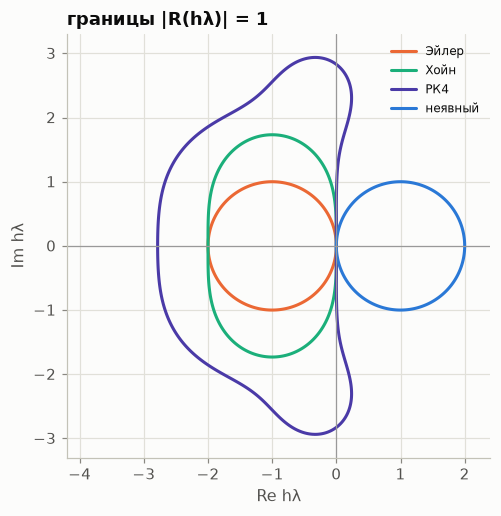

In [18]:
R = {
    "Эйлер": lambda z: 1 + z,
    "Хойн": lambda z: 1 + z + z**2 / 2,
    "РК4": lambda z: 1 + z + z**2 / 2 + z**3 / 6 + z**4 / 24,
    "неявный": lambda z: 1 / (1 - z),
}
print("РК4: вещественная граница", brentq(lambda x: abs(R["РК4"](x)) - 1, -3.5, -1))
print("РК4: граница на мнимой оси", brentq(lambda w: abs(R["РК4"](1j * w)) - 1, 1, 3.5), "= 2√2 =", 2 * math.sqrt(2))
print("Хойн: вещественная граница", brentq(lambda x: abs(R["Хойн"](x)) - 1, -3, -1))
xr, yr = np.meshgrid(np.linspace(-4.2, 2.4, 400), np.linspace(-3.3, 3.3, 400))
Z = xr + 1j * yr
fig, ax = plt.subplots(figsize=(6.5, 5))
for (name, fn), col in zip(R.items(), (ORANGE, AQUA, VIOLET, BLUE)):
    ax.contour(xr, yr, np.abs(fn(Z)), levels=[1], colors=[col], linewidths=2)
    ax.plot([], [], color=col, label=name)
ax.axhline(0, color="0.6", lw=0.8)
ax.axvline(0, color="0.6", lw=0.8)
ax.set(aspect="equal", xlabel="Re hλ", ylabel="Im hλ", title="границы |R(hλ)| = 1")
ax.legend(fontsize=8)
plt.show()

### Шаг 17. Хойн и Рунге — Кутта

In [19]:
for h in (0.2, 0.1):
    errs = [abs(solve(lambda t, y: -y, 1.0, 2.0, h, m)[1][-1] - math.exp(-2)) for m in ("euler", "heun", "mid", "rk4")]
    print(f"y′ = −y, h = {h}: Эйлер {errs[0]:.4f}, Хойн {errs[1]:.5f}, ср. точка {errs[2]:.5f}, РК4 {errs[3]:.2e}")
for m in ("euler", "heun", "rk4"):
    print(f"y′ = y, h = 0.25, {m:5}: y(1) = {solve(lambda t, y: y, 1.0, 1.0, 0.25, m)[1][-1]:.5f}")
k1, k2, k3 = 1, 1.5, 1.75
k4 = 1 + k3
print("один шаг РК4 с h = 1:", 1 + (k1 + 2 * k2 + 2 * k3 + k4) / 6, "= 1 + 1 + 1/2 + 1/6 + 1/24 =", 1 + 1 + 1 / 2 + 1 / 6 + 1 / 24)
e_eu = abs(solve(lambda t, y: -y, 1.0, 2.0, 0.1, "euler")[1][-1] - math.exp(-2))
e_rk = abs(solve(lambda t, y: -y, 1.0, 2.0, 0.4, "rk4")[1][-1] - math.exp(-2))
print(f"20 вычислений f: Эйлер (h = 0.1) {e_eu:.4f}, РК4 (h = 0.4) {e_rk:.1e}")

y′ = −y, h = 0.2: Эйлер 0.0280, Хойн 0.00211, ср. точка 0.00211, РК4 4.27e-06
y′ = −y, h = 0.1: Эйлер 0.0138, Хойн 0.00049, ср. точка 0.00049, РК4 2.45e-07
y′ = y, h = 0.25, euler: y(1) = 2.44141
y′ = y, h = 0.25, heun : y(1) = 2.69486
y′ = y, h = 0.25, rk4  : y(1) = 2.71821
один шаг РК4 с h = 1: 2.708333333333333 = 1 + 1 + 1/2 + 1/6 + 1/24 = 2.708333333333333
20 вычислений f: Эйлер (h = 0.1) 0.0138, РК4 (h = 0.4) 8.1e-05


### Шаг 18. Адаптивный шаг (пара Эйлер — Хойн) и `solve_ivp`

In [20]:
fa = lambda t, y: 10 * y * (1 - y)  # noqa: E731
exa = lambda t: 1 / (1 + 999 * math.exp(-10 * t))  # noqa: E731


def adaptive(tol):
    t, y, h, n, rej, me = 0.0, 1e-3, 0.05, 0, 0, 0.0
    while t < 2 - 1e-12:
        h = min(h, 2 - t)
        k1 = fa(t, y)
        k2 = fa(t + h, y + h * k1)
        err, sc = h * abs(k2 - k1) / 2, tol * (1e-3 + abs(y))
        if err <= sc:
            t, y, n = t + h, y + h * (k1 + k2) / 2, n + 1
            me = max(me, abs(y - exa(t)))
        else:
            rej += 1
        h *= min(4, max(0.2, 0.9 * math.sqrt(sc / max(err, 1e-300))))
    return n, rej, me


def fixed_err(N):
    h, y, m = 2 / N, 1e-3, 0.0
    for i in range(N):
        k1 = fa(i * h, y)
        y += h * (k1 + fa(i * h + h, y + h * k1)) / 2
        m = max(m, abs(y - exa(i * h + h)))
    return m


for tol in (1e-2, 1e-3, 1e-4):
    n, rej, me = adaptive(tol)
    N = 10
    while fixed_err(N) > me:
        N = math.ceil(N * 1.05)
    print(f"tol = {tol:g}: принято {n}, отвергнуто {rej}, max ошибка {me:.1e}; постоянному шагу нужно ≈ {N}")
s = solve_ivp(fa, (0, 2), [1e-3], rtol=1e-6, atol=1e-9)
print("solve_ivp RK45: шагов", len(s.t) - 1, " ошибка в конце", abs(s.y[0, -1] - exa(2)))

tol = 0.01: принято 60, отвергнуто 3, max ошибка 5.5e-03; постоянному шагу нужно ≈ 126
tol = 0.001: принято 175, отвергнуто 5, max ошибка 7.1e-04; постоянному шагу нужно ≈ 351
tol = 0.0001: принято 537, отвергнуто 5, max ошибка 8.6e-05; постоянному шагу нужно ≈ 1043
solve_ivp RK45: шагов 44  ошибка в конце 1.0793030269518056e-07


## Блок 4. Второй порядок и системы

### Шаг 19. Затухающий осциллятор

In [21]:
for cc in (0.4, 1, 2, 3):
    print(f"c = {cc}: корни {np.round(np.roots([1, cc, 1]), 3)}")
print("период при c = 0.4:", 2 * math.pi / math.sqrt(1 - 0.04), " множитель за период:", math.exp(-0.2 * 2 * math.pi / math.sqrt(0.96)))


def settle(cc):
    s = solve_ivp(lambda t, u: [u[1], -u[0] - cc * u[1]], (0, 60), [1, 0], max_step=0.005, rtol=1e-9)
    big = np.nonzero(np.abs(s.y[0]) > 0.05)[0]
    return s.t[big[-1] + 1]


print("установление в ±5 %:", {cc: round(settle(cc), 2) for cc in (0.4, 1, 1.5, 2, 2.5, 3, 4)})

c = 0.4: корни [-0.2+0.98j -0.2-0.98j]
c = 1: корни [-0.5+0.866j -0.5-0.866j]
c = 2: корни [-1. -1.]
c = 3: корни [-2.618 -0.382]
период при c = 0.4: 6.41274915080932  множитель за период: 0.2773292556390075


установление в ±5 %: {0.4: np.float64(13.75), 1: np.float64(5.29), 1.5: np.float64(3.13), 2: np.float64(4.74), 2.5: np.float64(6.57), 3: np.float64(8.26), 4: np.float64(11.46)}


### Шаг 20. Линейные системы: след, определитель, собственные числа

In [22]:
for name, A in {
    "пружина с трением": [[0, 1], [-1, -0.5]],
    "седло": [[1, 0], [0, -1]],
    "пример 3": [[-1, 2], [-1, 0]],
}.items():
    A = np.array(A, dtype=float)
    lam_ = np.linalg.eigvals(A)
    print(f"{name:18}: τ = {np.trace(A):+.2f}, Δ = {np.linalg.det(A):+.2f}, τ² − 4Δ = {np.trace(A) ** 2 - 4 * np.linalg.det(A):+.2f}, λ = {np.round(lam_, 4)}")
print("период фокуса примера 3:", 2 * math.pi / abs(np.linalg.eigvals([[-1, 2], [-1, 0]])[0].imag))

пружина с трением : τ = -0.50, Δ = +1.00, τ² − 4Δ = -3.75, λ = [-0.25+0.9682j -0.25-0.9682j]
седло             : τ = +0.00, Δ = -1.00, τ² − 4Δ = +4.00, λ = [ 1.+0.j -1.+0.j]
пример 3          : τ = -1.00, Δ = +2.00, τ² − 4Δ = -7.00, λ = [-0.5+1.3229j -0.5-1.3229j]
период фокуса примера 3: 4.749641646894904


### Шаг 21. Маятник: период через эллиптический интеграл

In [23]:
for A_deg in (10, 45, 90, 170):
    A = math.radians(A_deg)
    Tex = 4 * ellipk(math.sin(A / 2) ** 2)
    a_, b_ = 1.0, math.cos(A / 2)
    for _ in range(30):
        a_, b_ = (a_ + b_) / 2, math.sqrt(a_ * b_)
    s = solve_ivp(lambda t, u: [u[1], -math.sin(u[0])], (0, 30), [A, 0], rtol=1e-11, atol=1e-12, events=lambda t, u: u[1])
    tz = [t for t in s.t_events[0] if t > 0.1]
    print(f"{A_deg:3d}°: период {Tex:.4f} (AGM {2 * math.pi / a_:.4f}, численно {2 * tz[0]:.4f}), отношение к 2π {Tex / (2 * math.pi):.4f}")

 10°: период 6.2952 (AGM 6.2952, численно 6.2952), отношение к 2π 1.0019
 45°: период 6.5343 (AGM 6.5343, численно 6.5343), отношение к 2π 1.0400
 90°: период 7.4163 (AGM 7.4163, численно 7.4163), отношение к 2π 1.1803


170°: период 15.3270 (AGM 15.3270, численно 15.3270), отношение к 2π 2.4394

### Шаг 22. Хищник — жертва и SIR

In [24]:
lv = lambda t, u: [u[0] * (1 - 0.5 * u[1]), u[1] * (-0.75 + 0.25 * u[0])]  # noqa: E731
Vlv = lambda u: 0.25 * u[0] - 0.75 * np.log(u[0]) + 0.5 * u[1] - np.log(u[1])  # noqa: E731
s = ivp(lv, [5.0, 1.0], 30)
print("Лотка — Вольтерра: V(30) − V(0) =", Vlv(s.y[:, -1]) - Vlv([5, 1]), "; период малых циклов 2π/√0.75 =", 2 * math.pi / math.sqrt(0.75))
beta, gam = 0.5, 0.2
sir = lambda t, u: [-beta * u[0] * u[1], beta * u[0] * u[1] - gam * u[1], gam * u[1]]  # noqa: E731
for v in (0.0, 0.3, 0.5, 0.6):
    s = ivp(sir, [(1 - v) * 0.999, 0.001, 0.0], 600, rtol=1e-10, atol=1e-12)
    tt_ = np.linspace(0, 600, 600001)
    I_ = s.sol(tt_)[1]
    print(f"привито {v:.0%}: пик {I_.max():.1%} на день {tt_[I_.argmax()]:.1f}, S в пике {s.sol(tt_[I_.argmax()])[0]:.3f}, переболело {s.y[2, -1]:.1%}")
for R0 in (1.5, 2, 2.5, 3):
    z = brentq(lambda z, R0=R0: 1 - z - math.exp(-R0 * z), 1e-9, 1)
    print(f"R0 = {R0}: итоговая доля переболевших {z:.3f}, порог иммунитета {1 - 1 / R0:.0%}")

Лотка — Вольтерра: V(30) − V(0) =

 7.398748280706968e-12 ; период малых циклов 2π/√0.75 = 7.255197456936871
привито 0%: пик 23.4% на день 24.4, S в пике 0.400, переболело 89.3%
привито 30%: пик 7.7% на день 39.8, S в пике 0.400, переболело 50.0%


привито 50%: пик 1.2% на день 74.8, S в пике 0.400, переболело 18.9%
привито 60%: пик 0.1% на день 0.0, S в пике 0.400, переболело 2.8%
R0 = 1.5: итоговая доля переболевших 0.583, порог иммунитета 33%
R0 = 2: итоговая доля переболевших 0.797, порог иммунитета 50%
R0 = 2.5: итоговая доля переболевших 0.893, порог иммунитета 60%
R0 = 3: итоговая доля переболевших 0.940, порог иммунитета 67%


### Шаг 23. Дрейф энергии: Эйлер, неявный, симплектический, РК4

In [25]:
h, n = 0.1, 100
res = {}
for name in ("euler", "implicit", "sympl"):
    x, v = 1.0, 0.0
    for _ in range(n):
        if name == "euler":
            x, v = x + h * v, v - h * x
        elif name == "implicit":
            x, v = (x + h * v) / (1 + h * h), (v - h * x) / (1 + h * h)
        else:
            v = v - h * x
            x = x + h * v
    res[name] = (x, v)
_, ur = solve(lambda t, u: np.array([u[1], -u[0]]), [1.0, 0.0], 10, 0.1)
print("энергия x² + v² после 100 шагов:", {k_: round(x * x + v * v, 6) for k_, (x, v) in res.items()}, "РК4", round(float(ur[-1] @ ur[-1]), 7))
print("теория: Эйлер (1 + h²)^n =", (1 + h * h) ** n, " радиус", (1 + h * h) ** (n / 2), "; РК4 (1 − h⁶/72)^n =", (1 - h**6 / 72) ** n)
# инвариант симплектического Эйлера: x² + v² − h·x·v
x, v = 1.0, 0.0
I0 = x * x + v * v - h * x * v
for _ in range(1000):
    v = v - h * x
    x = x + h * v
print("симплектический: x² + v² − hxv в начале и после 1000 шагов:", I0, x * x + v * v - h * x * v)

энергия x² + v² после 100 шагов: {'euler': 2.704814, 'implicit': 0.369711, 'sympl': 0.955629} РК4 0.9999986
теория: Эйлер (1 + h²)^n = 2.7048138294215285  радиус 1.6446318218438827 ; РК4 (1 − h⁶/72)^n = 0.9999986111120621
симплектический: x² + v² − hxv в начале и после 1000 шагов: 1.0 0.9999999999999977


## Блок 5. Дифференциальные уравнения в машинном обучении

### Шаг 24. Градиентный спуск — метод Эйлера для градиентного потока

In [26]:
for eta in (0.1, 0.5, 1.0, 1.5, 1.9, 2.1):
    print(f"η = {eta}: через 10 шагов θ = {(1 - eta) ** 10:+.4f}; поток к t = 10η: {math.exp(-10 * eta):.4f}")
# две ямы: L″(±1) = 2, граница η < 1
for eta in (0.5, 0.95, 1.05):
    th = 0.3
    for _ in range(200):
        th -= eta * (th**3 - th)
    print(f"две ямы, η = {eta}: θ после 200 шагов = {th:+.5f}")

η = 0.1: через 10 шагов θ = +0.3487; поток к t = 10η: 0.3679
η = 0.5: через 10 шагов θ = +0.0010; поток к t = 10η: 0.0067
η = 1.0: через 10 шагов θ = +0.0000; поток к t = 10η: 0.0000
η = 1.5: через 10 шагов θ = +0.0010; поток к t = 10η: 0.0000
η = 1.9: через 10 шагов θ = +0.3487; поток к t = 10η: 0.0000
η = 2.1: через 10 шагов θ = +2.5937; поток к t = 10η: 0.0000
две ямы, η = 0.5: θ после 200 шагов = +1.00000
две ямы, η = 0.95: θ после 200 шагов = +1.00000
две ямы, η = 1.05: θ после 200 шагов = +0.87287


### Шаги 25–26. Обусловленность и моментум

In [27]:
lamv = np.array([1.0, 10.0])


def run(eta, beta=0.0, lam_=lamv, start=(2.0, 1.0), tol=1e-3):
    th = prev = np.array(start)
    for k_ in range(1, 20001):
        th, prev = th - eta * lam_ * th + beta * (th - prev), th
        if np.linalg.norm(th) < tol:
            return k_
    return None


kap = 10
b_opt = ((math.sqrt(kap) - 1) / (math.sqrt(kap) + 1)) ** 2
e_opt = 4 / (1 + math.sqrt(kap)) ** 2
print(f"κ = 10: лучший η = {2 / 11:.4f} → {run(2 / 11)} шагов; η = 0.1 → {run(0.1)}; моментум (η = {e_opt:.3f}, β = {b_opt:.3f}) → {run(e_opt, b_opt)}")
for kap in (100, 1000):
    lam_ = np.array([1.0, kap])
    rg, rh = (kap - 1) / (kap + 1), (math.sqrt(kap) - 1) / (math.sqrt(kap) + 1)
    print(f"κ = {kap}: до 1e−6 по теории спуск {math.log(1e-6) / math.log(rg):.0f}, моментум {math.log(1e-6) / math.log(rh):.0f}; "
          f"симуляция из (1, 1): {run(2 / (1 + kap), lam_=lam_, start=(1, 1), tol=1e-6)} и "
          f"{run(4 / (1 + math.sqrt(kap)) ** 2, ((math.sqrt(kap) - 1) / (math.sqrt(kap) + 1)) ** 2, lam_=lam_, start=(1, 1), tol=1e-6)}")
# моментум — дискретизация θ″ + γθ′ + θ = 0 с β = 1 − γh, η = h²: при h → 0 траектории сближаются как O(h)
gamma_ = 1.0
s = solve_ivp(lambda t, u: [u[1], -gamma_ * u[1] - u[0]], (0, 20), [1, 0], rtol=1e-11, atol=1e-12, dense_output=True)
for h in (0.2, 0.1, 0.05, 0.01):
    th = prev = 1.0
    traj = [th]
    for _ in range(round(20 / h)):
        th, prev = th - h * h * th + (1 - gamma_ * h) * (th - prev), th
        traj.append(th)
    tk = np.arange(len(traj)) * h
    print(f"h = {h:<4}: max |моментум − осциллятор| = {np.max(np.abs(np.array(traj) - s.sol(tk)[0])):.4f}")

κ = 10: лучший η = 0.1818 → 39 шагов; η = 0.1 → 73; моментум (η = 0.231, β = 0.270) → 16
κ = 100: до 1e−6 по теории спуск 691, моментум 69; симуляция из (1, 1): 709 и 95
κ = 1000: до 1e−6 по теории спуск 6908, моментум 218; симуляция из (1, 1): 7082 и 321
h = 0.2 : max |моментум − осциллятор| = 0.0842
h = 0.1 : max |моментум − осциллятор| = 0.0414
h = 0.05: max |моментум − осциллятор| = 0.0206
h = 0.01: max |моментум − осциллятор| = 0.0041


### Шаг 27. Бустинг — метод Эйлера в пространстве прогнозов

Одна группа объектов (квадратичные потери, цель 10): остаток $(1 - \nu)^M$ против $e^{-t}$.

In [28]:
for nu in (0.1, 0.5, 1.5):
    print(f"ν = {nu}: остаток к t = 3: {10 * abs(1 - nu) ** round(3 / nu):.3f} (поток {10 * math.exp(-3):.3f})")
# log-loss, все объекты листа — единицы: градиентный поток F + e^F = t + 1, поток Ньютона F = ln(2eᵗ − 1)
for t in (10, 100, 1000):
    F = brentq(lambda F, t=t: F + math.exp(F) - (t + 1), -5, 20)
    print(f"t = {t}: градиентный поток F = {F:.3f} (ln t = {math.log(t):.3f}); поток Ньютона F = {math.log(2 * math.exp(min(t, 700)) - 1):.3f}")
# устойчивость градиентного шага для log-loss: ν < 2/(p(1 − p))
for nu in (9.0, 9.6):
    F = 0.0
    for _ in range(300):
        F += nu * (0.7 - 1 / (1 + math.exp(-F)))
    print(f"p̄ = 0.7, ν = {nu}: F = {F:.4f} (равновесие {math.log(7 / 3):.4f}, граница {2 / 0.21:.2f})")

ν = 0.1: остаток к t = 3: 0.424 (поток 0.498)
ν = 0.5: остаток к t = 3: 0.156 (поток 0.498)
ν = 1.5: остаток к t = 3: 2.500 (поток 0.498)
t = 10: градиентный поток F = 2.177 (ln t = 2.303); поток Ньютона F = 10.693
t = 100: градиентный поток F = 4.569 (ln t = 4.605); поток Ньютона F = 100.693
t = 1000: градиентный поток F = 6.902 (ln t = 6.908); поток Ньютона F = 700.693
p̄ = 0.7, ν = 9.0: F = 0.8473 (равновесие 0.8473, граница 9.52)
p̄ = 0.7, ν = 9.6: F = 0.6058 (равновесие 0.8473, граница 9.52)


На данных: бустинг с разными $\nu$ в координатах «времени» $t = \nu M$ даёт близкие потери на обучении — бустинг
с малым шагом приближает поток. В классификации `gbcourse` (листья Фридмана — шаг Ньютона) на разделимых данных
отступы растут линейно, как поток Ньютона $F = \ln(2e^t - 1)$, и не останавливаются.

ν = 0.5 : MSE при t = 1, 2, 4 → [0.2155 0.1158 0.0728]
ν = 0.2 : MSE при t = 1, 2, 4 → [0.2536 0.1253 0.0728]


ν = 0.05: MSE при t = 1, 2, 4 → [0.2712 0.1313 0.0754]


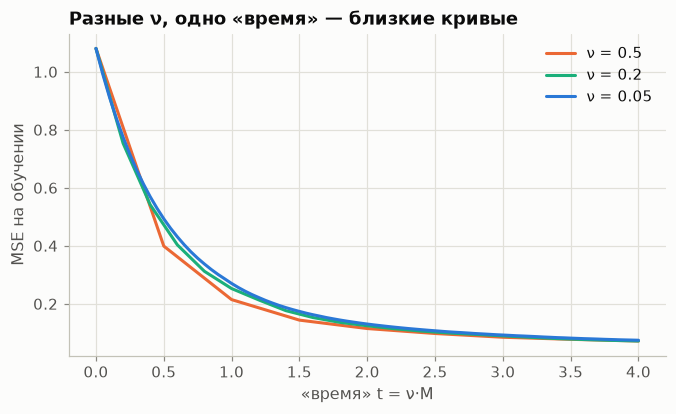

t =  5: наименьший отступ 5.726, поток Ньютона ln(2eᵗ − 1) = 5.690
t = 10: наименьший отступ 10.729, поток Ньютона ln(2eᵗ − 1) = 10.693
t = 20: наименьший отступ 20.729, поток Ньютона ln(2eᵗ − 1) = 20.693


In [29]:
X, y = datasets.regression_1d(kind="wave", n=200, noise=0.3, seed=5)
fig, ax = plt.subplots(figsize=(7, 3.8))
for nu, col in ((0.5, ORANGE), (0.2, AQUA), (0.05, BLUE)):
    M = round(4 / nu)
    model = GBRegressor(n_estimators=M, learning_rate=nu, max_depth=2).fit(X, y)
    mse = np.array([np.mean((y - model.predict(X, n_iter=m)) ** 2) for m in range(M + 1)])
    ax.plot(np.arange(M + 1) * nu, mse, color=col, lw=2, label=f"ν = {nu}")
    print(f"ν = {nu:<4}: MSE при t = 1, 2, 4 →", np.round(mse[[round(1 / nu), round(2 / nu), M]], 4))
ax.set(xlabel="«время» t = ν·M", ylabel="MSE на обучении", title="Разные ν, одно «время» — близкие кривые")
ax.legend()
plt.show()

Xc, yc = datasets.classification_2d(kind="blobs", n=200, noise=0.2, seed=3)
clf = GBClassifier(n_estimators=200, learning_rate=0.1, max_depth=2).fit(Xc, yc)
for t in (5, 10, 20):
    F = clf.predict_raw(Xc, n_iter=round(t / 0.1))
    marg = np.where(yc == 1, F, -F)
    print(f"t = {t:2d}: наименьший отступ {marg.min():.3f}, поток Ньютона ln(2eᵗ − 1) = {math.log(2 * math.exp(t) - 1):.3f}")

### Шаг 28. Неявный шаг и λ в XGBoost

Лист с $G = -4$, $H = 2$ (8 объектов класса 1 при $p = 0.5$): XGBoost с одним деревом и `eta = 1` даёт ровно
$-G/(H + \lambda)$.

In [30]:
for z in (0.5, 1, 2, 5):
    print(f"ηa = {z}: явный множитель {1 - z:+.2f}, неявный {1 / (1 + z):.3f}")
try:
    import xgboost as xgb

    X8, y8 = np.zeros((8, 1)), np.ones(8)
    for lam_ in (0, 1, 10):
        bst = xgb.train({"objective": "binary:logistic", "eta": 1, "lambda": lam_, "base_score": 0.5, "min_child_weight": 0, "max_depth": 1},
                        xgb.DMatrix(X8, label=y8), 1)
        w = bst.predict(xgb.DMatrix(X8), output_margin=True)[0]
        print(f"λ = {lam_:2d}: лист XGBoost {w:.4f}, −G/(H + λ) = {4 / (2 + lam_):.4f}" + (f", градиентный шаг −G/λ = {4 / lam_:.4f}" if lam_ else " (Ньютон)"))
except ImportError:
    print("xgboost не установлен — пропускаем")

ηa = 0.5: явный множитель +0.50, неявный 0.667
ηa = 1: явный множитель +0.00, неявный 0.500
ηa = 2: явный множитель -1.00, неявный 0.333
ηa = 5: явный множитель -4.00, неявный 0.167


λ =  0: лист XGBoost 2.0000, −G/(H + λ) = 2.0000 (Ньютон)
λ =  1: лист XGBoost 1.3333, −G/(H + λ) = 1.3333, градиентный шаг −G/λ = 4.0000
λ = 10: лист XGBoost 0.3333, −G/(H + λ) = 0.3333, градиентный шаг −G/λ = 0.4000


## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Распад: $y' = -0.2y$, $y(0) = 50$.
2. ★☆☆ Бак с рассолом: составить уравнение и найти соль через час.
3. ★★☆ Равновесия и устойчивость $y' = y(y - 1)(y - 3)$.
4. ★★☆ Разделение переменных: $y' = y\cos t$; взрыв $y' = y^3$.
5. ★★☆ Линейное уравнение $y' + 2y = 4t$.
6. ★★☆ Наибольший устойчивый шаг для $y' = -50y$; неявный метод.
7. ★★☆ Порядок методов: оценить по двум шагам.
8. ★★☆ Осциллятор: режимы и критическое трение.
9. ★★★ Энергия пружины: множитель $1 + h^2$ и инвариант симплектического Эйлера.
10. ★★★ Спуск по $L = 2\theta_1^2 + 8\theta_2^2$: темпы и множители.
11. ★★★ SIR: порог коллективного иммунитета и итоговая доля.
12. ★★★ Бустинг с log-loss: граница темпа и поток Ньютона.